try a map to compare t90 to location

In [10]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

Cell 2 — Load  dataset

In [11]:
event_df = pd.read_csv(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_clean.csv"
)

# Ensure consistent formatting
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

print(event_df.head())

                            event_id          storm CountyFIPS         t90  \
0  2017212N28275_2017-07-30 21:00:00  2017212N28275      12075    1.885185   
1  2017242N16333_2017-09-09 19:00:00  2017242N16333      12037  120.406155   
2  2017242N16333_2017-09-09 20:00:00  2017242N16333      12067  186.802564   
3  2017242N16333_2017-09-09 21:00:00  2017242N16333      12013   52.651220   
4  2017242N16333_2017-09-09 22:00:00  2017242N16333      12075  170.764203   

   t90_censored   max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  \
0             0  12.601287      7.421799        67.413998      1009.864246   
1             0  27.279316     12.005697        92.750718       995.318712   
2             0  33.241034      9.333728       153.916280       982.833530   
3             0  25.291777     14.104932        89.230104       996.010565   
4             0  33.169058      9.553964       145.733609       976.919507   

   max_customers_tracked  county_pop  
0                 3862.

Cell 3 — Load US counties geometry

In [12]:
# US counties (GeoJSON, no download needed)
url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"

counties = gpd.read_file(url)

# The key column is "id"
counties = counties.rename(columns={"id": "CountyFIPS"})

print(counties.head())

  CountyFIPS          GEO_ID STATE COUNTY      NAME    LSAD  CENSUSAREA  \
0      01001  0500000US01001    01    001   Autauga  County     594.436   
1      01009  0500000US01009    01    009    Blount  County     644.776   
2      01017  0500000US01017    01    017  Chambers  County     596.531   
3      01021  0500000US01021    01    021   Chilton  County     692.854   
4      01033  0500000US01033    01    033   Colbert  County     592.619   

                                            geometry  
0  POLYGON ((-86.49677 32.34444, -86.7179 32.4028...  
1  POLYGON ((-86.5778 33.76532, -86.75914 33.8406...  
2  POLYGON ((-85.18413 32.87052, -85.12342 32.772...  
3  POLYGON ((-86.51734 33.02057, -86.51596 32.929...  
4  POLYGON ((-88.13999 34.5817, -88.13925 34.5878...  


Cell 4 — Filter to Florida

In [13]:
fl_counties = counties[counties["CountyFIPS"].str.startswith("12")].copy()

print(len(fl_counties))

67


Cell 5 — Pick a storm (e.g. Michael)

In [14]:
storm_id = "2018280N18273"  # Michael
# storm_id = "2017242N16333"  # Irma


storm_df = event_df[event_df["storm"] == storm_id].copy()

print(storm_df[["CountyFIPS", "t90"]])

   CountyFIPS         t90
50      12063  551.473029
51      12077  376.389362
52      12129  129.915167
53      12045  439.371951
54      12037  149.312003
55      12039  320.967260
56      12059  201.907101
57      12005  466.967058
58      12131   54.128338
59      12013  509.506513
60      12073  123.431518
61      12133  354.097926
62      12065   48.350602
63      12079   10.852542


Cell 6 — Merge geometry with your data

In [15]:
map_df = fl_counties.merge(
    storm_df,
    on="CountyFIPS",
    how="left"
)

print(map_df[["CountyFIPS", "t90"]].head())

  CountyFIPS  t90
0      12083  NaN
1      12087  NaN
2      12095  NaN
3      12111  NaN
4      12119  NaN


Cell 7 — Plot choropleth

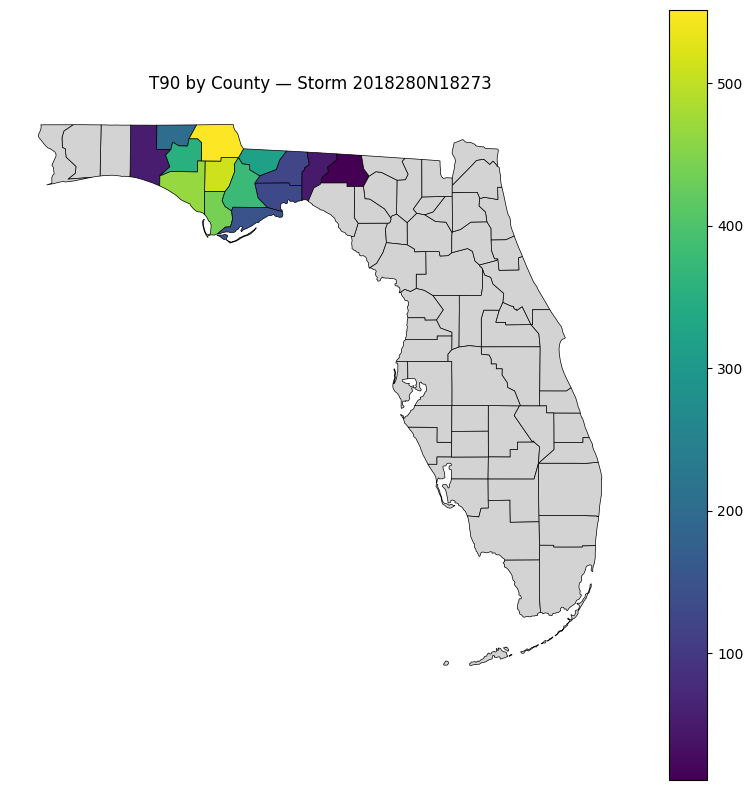

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

map_df.plot(
    column="t90",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(f"T90 by County — Storm {storm_id}")
ax.axis("off")

plt.show()

Goal

Find adjacent counties within the same storm where:

one has high t90
one has low t90

Then inspect their:

outage trajectories
weather
customersTracked

In [17]:
clean_ts_df = pd.read_parquet(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_timeseries_clean.parquet"
)

clean_ts_df["datetime"] = pd.to_datetime(clean_ts_df["datetime"])
clean_ts_df["event_start"] = pd.to_datetime(clean_ts_df["event_start"])
clean_ts_df["CountyFIPS"] = clean_ts_df["CountyFIPS"].astype(str).str.zfill(5)

print(clean_ts_df.shape)
print(clean_ts_df.head())

(16918, 12)
                            event_id          storm CountyFIPS  \
0  2017242N16333_2017-09-11 03:00:00  2017242N16333      12001   
1  2017242N16333_2017-09-11 03:00:00  2017242N16333      12001   
2  2017242N16333_2017-09-11 03:00:00  2017242N16333      12001   
3  2017242N16333_2017-09-11 03:00:00  2017242N16333      12001   
4  2017242N16333_2017-09-11 03:00:00  2017242N16333      12001   

             datetime         event_start  outageFraction  outage_clean  \
0 2017-09-10 15:00:00 2017-09-11 03:00:00        0.046551      0.043928   
1 2017-09-10 16:00:00 2017-09-11 03:00:00        0.043928      0.027465   
2 2017-09-10 17:00:00 2017-09-11 03:00:00        0.011002      0.011002   
3 2017-09-10 18:00:00 2017-09-11 03:00:00        0.003011      0.011002   
4 2017-09-10 19:00:00 2017-09-11 03:00:00        0.010880      0.011002   

    gust_mps  wind_speed_mps  precip_mm  pressure_hpa  customersTracked  
0   9.545648        6.145859   2.925622   1012.454131           97

Cell 1 — Load cleaned time series + event-level data

In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load datasets
event_df = pd.read_csv(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_clean.csv"
)

clean_ts_df = pd.read_parquet(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_timeseries_clean.parquet"
)

# Standardise
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)
clean_ts_df["CountyFIPS"] = clean_ts_df["CountyFIPS"].astype(str).str.zfill(5)

clean_ts_df["datetime"] = pd.to_datetime(clean_ts_df["datetime"])
clean_ts_df["event_start"] = pd.to_datetime(clean_ts_df["event_start"])

print(event_df.shape)
print(clean_ts_df.shape)

(90, 11)
(16918, 12)


Cell 2 — Load county geometries

In [19]:
# Load US counties
url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
counties = gpd.read_file(url)
counties = counties.rename(columns={"id": "CountyFIPS"})

# Florida only
counties = counties[counties["CountyFIPS"].str.startswith("12")].copy()

print(len(counties))

67


Cell 3 — Pick a storm and merge

In [20]:
storm_id = "2018280N18273"  # Michael

storm_df = event_df[event_df["storm"] == storm_id].copy()

geo_df = counties.merge(storm_df, on="CountyFIPS", how="inner")

print(geo_df.shape)
print(geo_df[["CountyFIPS", "t90"]].head())

(14, 18)
  CountyFIPS         t90
0      12013  509.506513
1      12039  320.967260
2      12059  201.907101
3      12073  123.431518
4      12131   54.128338


Cell 4 — Find adjacent counties with large t90 differences

In [21]:
pairs = []

for i, row_i in geo_df.iterrows():
    for j, row_j in geo_df.iterrows():
        if i >= j:
            continue
        
        if row_i.geometry.touches(row_j.geometry):
            diff = abs(row_i["t90"] - row_j["t90"])
            
            pairs.append({
                "county1": row_i["CountyFIPS"],
                "county2": row_j["CountyFIPS"],
                "t90_1": row_i["t90"],
                "t90_2": row_j["t90"],
                "diff": diff
            })

pairs_df = pd.DataFrame(pairs).sort_values("diff", ascending=False)

pairs_df.head(10)

,county1,county2,t90_1,t90_2,diff
14,12131,12005,54.128338,466.967058,412.838720
9,12059,12063,201.907101,551.473029,349.565928
15,12131,12133,54.128338,354.097926,299.969587
21,12045,12037,439.371951,149.312003,290.059948
12,12073,12077,123.431518,376.389362,252.957844
24,12129,12077,129.915167,376.389362,246.474195
6,12039,12063,320.967260,551.473029,230.505769
27,12077,12037,376.389362,149.312003,227.077359
5,12039,12073,320.967260,123.431518,197.535742
22,12063,12133,551.473029,354.097926,197.375103


Cell 5 — Pick one pair

In [28]:
pair = pairs_df.iloc[0]

c1 = pair["county1"]
c2 = pair["county2"]

print(pair)

# Get correct event_id for each county
event_id_1 = event_df[
    (event_df["storm"] == storm_id) &
    (event_df["CountyFIPS"] == c1)
]["event_id"].iloc[0]

event_id_2 = event_df[
    (event_df["storm"] == storm_id) &
    (event_df["CountyFIPS"] == c2)
]["event_id"].iloc[0]

print("event_id_1:", event_id_1)
print("event_id_2:", event_id_2)

county1         12131
county2         12005
t90_1       54.128338
t90_2      466.967058
diff        412.83872
Name: 14, dtype: object
event_id_1: 2018280N18273_2018-10-10 17:00:00
event_id_2: 2018280N18273_2018-10-10 17:00:00


Cell 6 — Extract time series

In [32]:
g1 = clean_ts_df[
    (clean_ts_df["event_id"] == event_id_1) &
    (clean_ts_df["CountyFIPS"] == c1)
].sort_values("datetime")

g2 = clean_ts_df[
    (clean_ts_df["event_id"] == event_id_2) &
    (clean_ts_df["CountyFIPS"] == c2)
].sort_values("datetime")

print("Lengths:", len(g1), len(g2))

Lengths: 80 528


Cell 7 — Plot outage_clean comparison

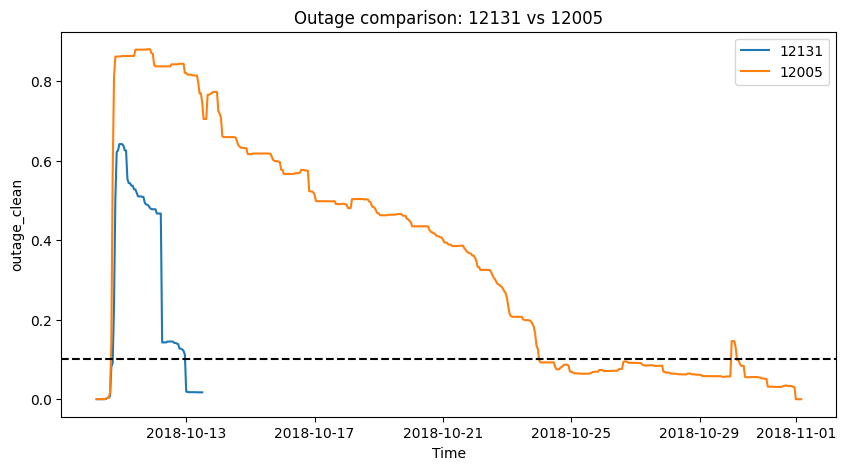

In [33]:
plt.figure(figsize=(10,5))

plt.plot(g1["datetime"], g1["outage_clean"], label=f"{c1}")
plt.plot(g2["datetime"], g2["outage_clean"], label=f"{c2}")

plt.axhline(0.1, linestyle="--", color="black")

plt.legend()
plt.title(f"Outage comparison: {c1} vs {c2}")
plt.xlabel("Time")
plt.ylabel("outage_clean")

plt.show()

Cell 8 — Compare weather

In [34]:
print("County 1:", c1)
print(g1[["gust_mps", "precip_mm", "pressure_hpa"]].describe())

print("\nCounty 2:", c2)
print(g2[["gust_mps", "precip_mm", "pressure_hpa"]].describe())

County 1: 12131
        gust_mps     precip_mm  pressure_hpa
count  80.000000  8.000000e+01     80.000000
mean    9.594886  8.467141e-01   1008.335900
std     5.451292  2.112335e+00      6.304752
min     2.436007 -9.313226e-07    992.261263
25%     5.849400  0.000000e+00   1004.670453
50%     8.216604  4.656613e-07   1011.236819
75%    12.179287  2.258695e-01   1013.121648
max    22.912481  1.032543e+01   1015.040746

County 2: 12005
         gust_mps   precip_mm  pressure_hpa
count  528.000000  528.000000    528.000000
mean     6.797709    0.191763   1016.543989
std      3.833789    0.899116      5.894010
min      1.249338   -0.000002    985.962528
25%      4.412617    0.000000   1014.459758
50%      5.969970    0.000000   1018.448215
75%      8.628621    0.002409   1020.051952
max     27.984700   12.540154   1024.275866


Cell 9 — Compare customersTracked

In [35]:
print("CustomersTracked comparison:")

print(c1)
print(g1["customersTracked"].describe())

print("\n", c2)
print(g2["customersTracked"].describe())

CustomersTracked comparison:
12131
count       80.000000
mean     39012.087500
std       6421.775761
min      25365.000000
25%      42164.000000
50%      42164.000000
75%      42164.000000
max      42164.000000
Name: customersTracked, dtype: float64

 12005
count       528.000000
mean     116701.251894
std       12339.468571
min           0.000000
25%      117719.000000
50%      117719.000000
75%      117843.000000
max      123951.000000
Name: customersTracked, dtype: float64


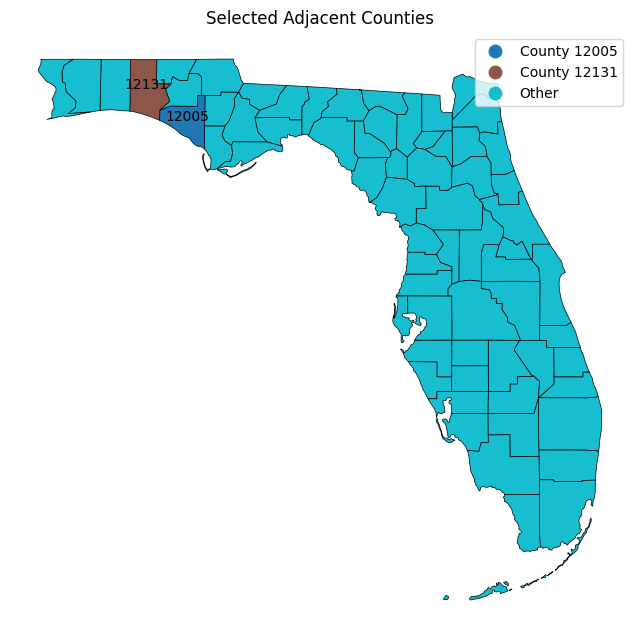

In [38]:
import matplotlib.pyplot as plt

# Load counties (same as before)
url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
counties = gpd.read_file(url)
counties = counties.rename(columns={"id": "CountyFIPS"})

# Florida only
counties = counties[counties["CountyFIPS"].str.startswith("12")].copy()

# Highlight counties
c1 = "12131"
c2 = "12005"

counties["highlight"] = "Other"
counties.loc[counties["CountyFIPS"] == c1, "highlight"] = "County 12131"
counties.loc[counties["CountyFIPS"] == c2, "highlight"] = "County 12005"

# Plot
fig, ax = plt.subplots(figsize=(8,8))

counties.plot(
    column="highlight",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

for idx, row in counties[counties["highlight"] != "Other"].iterrows():
    x, y = row.geometry.centroid.coords[0]
    ax.text(x, y, row["CountyFIPS"], fontsize=10, ha='center')

ax.set_title("Selected Adjacent Counties")
ax.axis("off")

plt.show()